In [6]:
import glob
import os

import ehtim as eh
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from eht_inspection.uvfits import *
from eht_inspection.plotting import plot_uv_coverage


/Users/ningyuanxu/mamba/envs/eht-py/bin/python


In [2]:
uvfits_files = sorted(glob.glob("**/*.uvfits", recursive=True))

print(f"Found {len(uvfits_files)} uvfits files:")
for i, f in enumerate(uvfits_files):
    print(i, f)

fname = uvfits_files[0]
print("\nUsing:", fname)

print("\nFITS structure:")
with fits.open(fname) as hdul:
    hdul.info()

print("\nLoading with eht-imaging...")
times, t1, t2, u, v, rr, rl, lr, ll, rrsigma, rlsigma, lrsigma, llsigma = load_obs_uvfits(fname, IF=all)
obs = eh.obsdata.load_uvfits(fname, IF=[0], polrep='circ', remove_nan=True)
obs.add_scans()
scans = obs.scans

scan_ids = np.full(len(times), -1, dtype=int)

for iscan, (t_start, t_stop) in enumerate(scans):
    if iscan == len(scans) - 1:
        in_scan = (times >= t_start) & (times <= t_stop)
    else:
        # half-open interval avoids double-counting records exactly on boundaries
        in_scan = (times >= t_start) & (times < t_stop)

    scan_ids[in_scan] = iscan

print(obs)
print("\nData fields:")
print(obs.data.dtype.names)

print("\nSites:")
print(obs.tarr["site"])

print("\nNumber of visibilities:", len(obs.data))

Found 2 uvfits files:
0 data/hops_3809_3C273.apriori+avg.uvfits
1 data/hops_3809_3C273.apriori.uvfits

Using: data/hops_3809_3C273.apriori+avg.uvfits

FITS structure:
Filename: data/hops_3809_3C273.apriori+avg.uvfits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 GroupsHDU       82   (3, 4, 1, 1, 1, 1)   float32   3618 Groups  9 Parameters
  1  AIPS AN       1 BinTableHDU     60   10R x 13C   [8A, 3D, 1E, 1J, 1J, 1E, 1A, 1E, 3E, 1A, 1E, 3E, 1D]   
  2  AIPS FQ       1 BinTableHDU     21   1R x 5C   [1J, 1D, 1E, 1E, 1J]   
  3  AIPS NX       1 BinTableHDU     26   0R x 7C   [1D, 1E, 1J, 1J, 1J, 1J, 1J]   

Loading with eht-imaging...
Loading uvfits:  data/hops_3809_3C273.apriori+avg.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
Loading uvfits:  data/hops_3809_3C273.apriori+avg.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4

Data fields:
('time', 'tint', 't1', 't

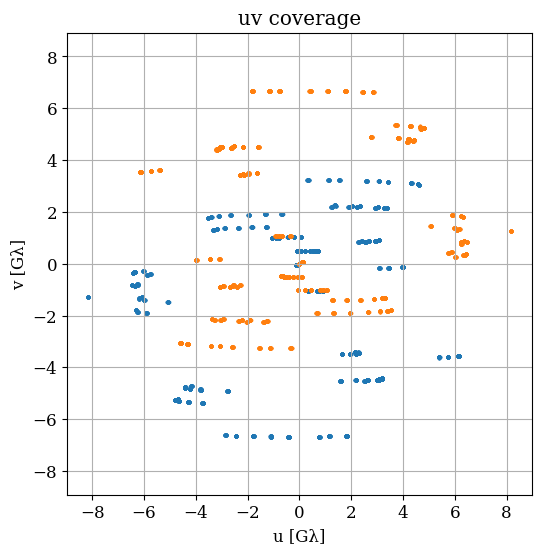

In [3]:
fig, ax = plot_uv_coverage(u, v)
plt.show()


For each baseline, for all 4 polarizations (in a single plot), show amp vs. channel, phase vs. channel for raw data

amp vs. time/scan/uv distance, phase vs. time/scan for channel-averaged, 10s-averaged data.

Raw data can tell you bandpass, bad channels, cross-pol channel structure

Averaged data can tell you scan-to-scan jumps, amplitude stability, and time-domain outliers

In [4]:
print(np.unique(scan_ids))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


In [5]:
result = build_scan_coherency_matrix(0, scan_ids, times, t1, t2, u, v, rr, rl, lr, ll)

### For Raw Data

The repo only has channel-averaged and 10s-averaged data due to size limit (~140MB)

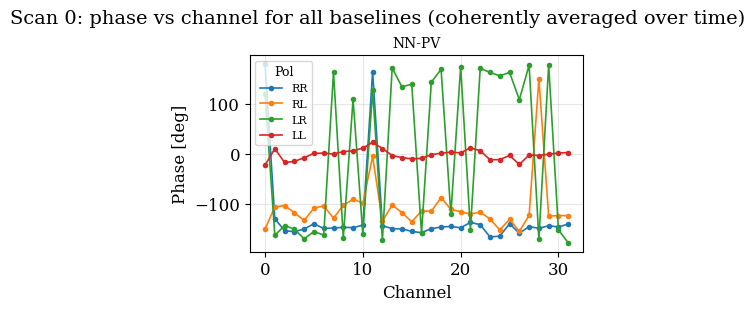

In [7]:
fig, axs = plot_scan_phase_vs_channel_all_baselines(
    allcoh=result["allcoh"],
    channel_list=result["channel_list"],
    station_list=result["station_list"],
    scan_num=result["scan_number"],
    average_over_time=True,
    unwrap_phase=False,
    source="3C273",
)

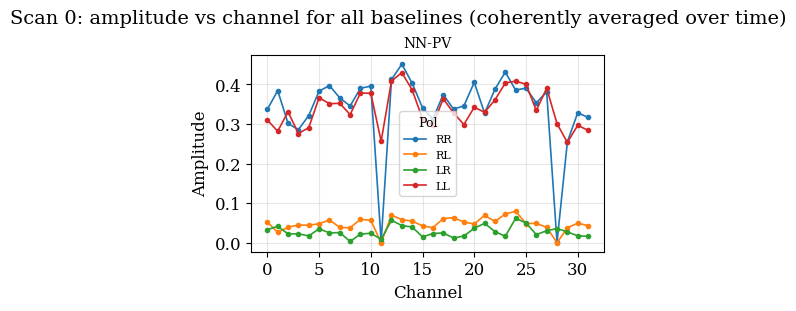

In [8]:
fig, axs = plot_scan_amp_vs_channel_all_baselines(
    allcoh=result["allcoh"],
    channel_list=result["channel_list"],
    station_list=result["station_list"],
    scan_num=result["scan_number"],
    average_over_time=True,
    source="3C273",
)

In [25]:
# Make one plot per scan
for sscan in np.unique(scan_ids):
    tmp_res = build_scan_coherency_matrix(sscan, scan_ids, times, t1, t2, u, v, rr, rl, lr, ll)

    fig, axs = plot_scan_phase_vs_channel_all_baselines(
        allcoh=tmp_res["allcoh"],
        channel_list=tmp_res["channel_list"],
        station_list=tmp_res["station_list"],
        scan_num=tmp_res["scan_number"],
        average_over_time=True,
        unwrap_phase=False,
        source="3C273",
    )

    plt.close(fig)
    del fig, axs

    fig, axs = plot_scan_amp_vs_channel_all_baselines(
        allcoh=tmp_res["allcoh"],
        channel_list=tmp_res["channel_list"],
        station_list=tmp_res["station_list"],
        scan_num=tmp_res["scan_number"],
        average_over_time=True,
        source="3C273",
    )

    plt.close(fig)
    del tmp_res
    del fig, axs
    
    

### For Averaged Data

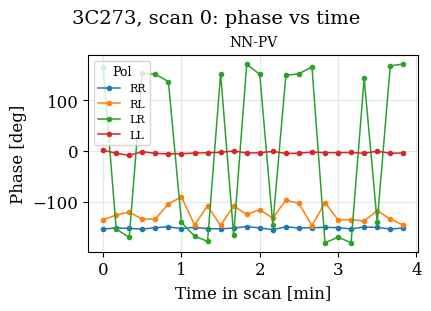

In [6]:
fig, ax = plot_result_phase_vs_time_all_baselines(result, source="3C273")

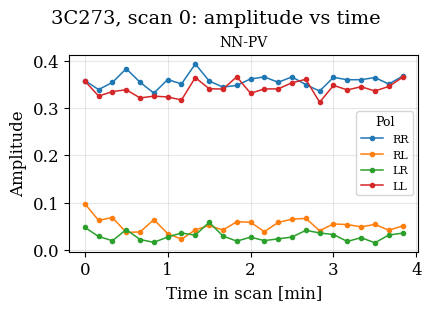

In [7]:
fig, ax = plot_result_amp_vs_time_all_baselines(result, source="3C273")

In [8]:
results = []

for sscan in np.unique(scan_ids):
    res = build_scan_coherency_matrix(
        sscan,
        scan_ids,
        times,
        t1,
        t2,
        u,
        v,
        rr,
        rl,
        lr,
        ll,
    )
    results.append(res)

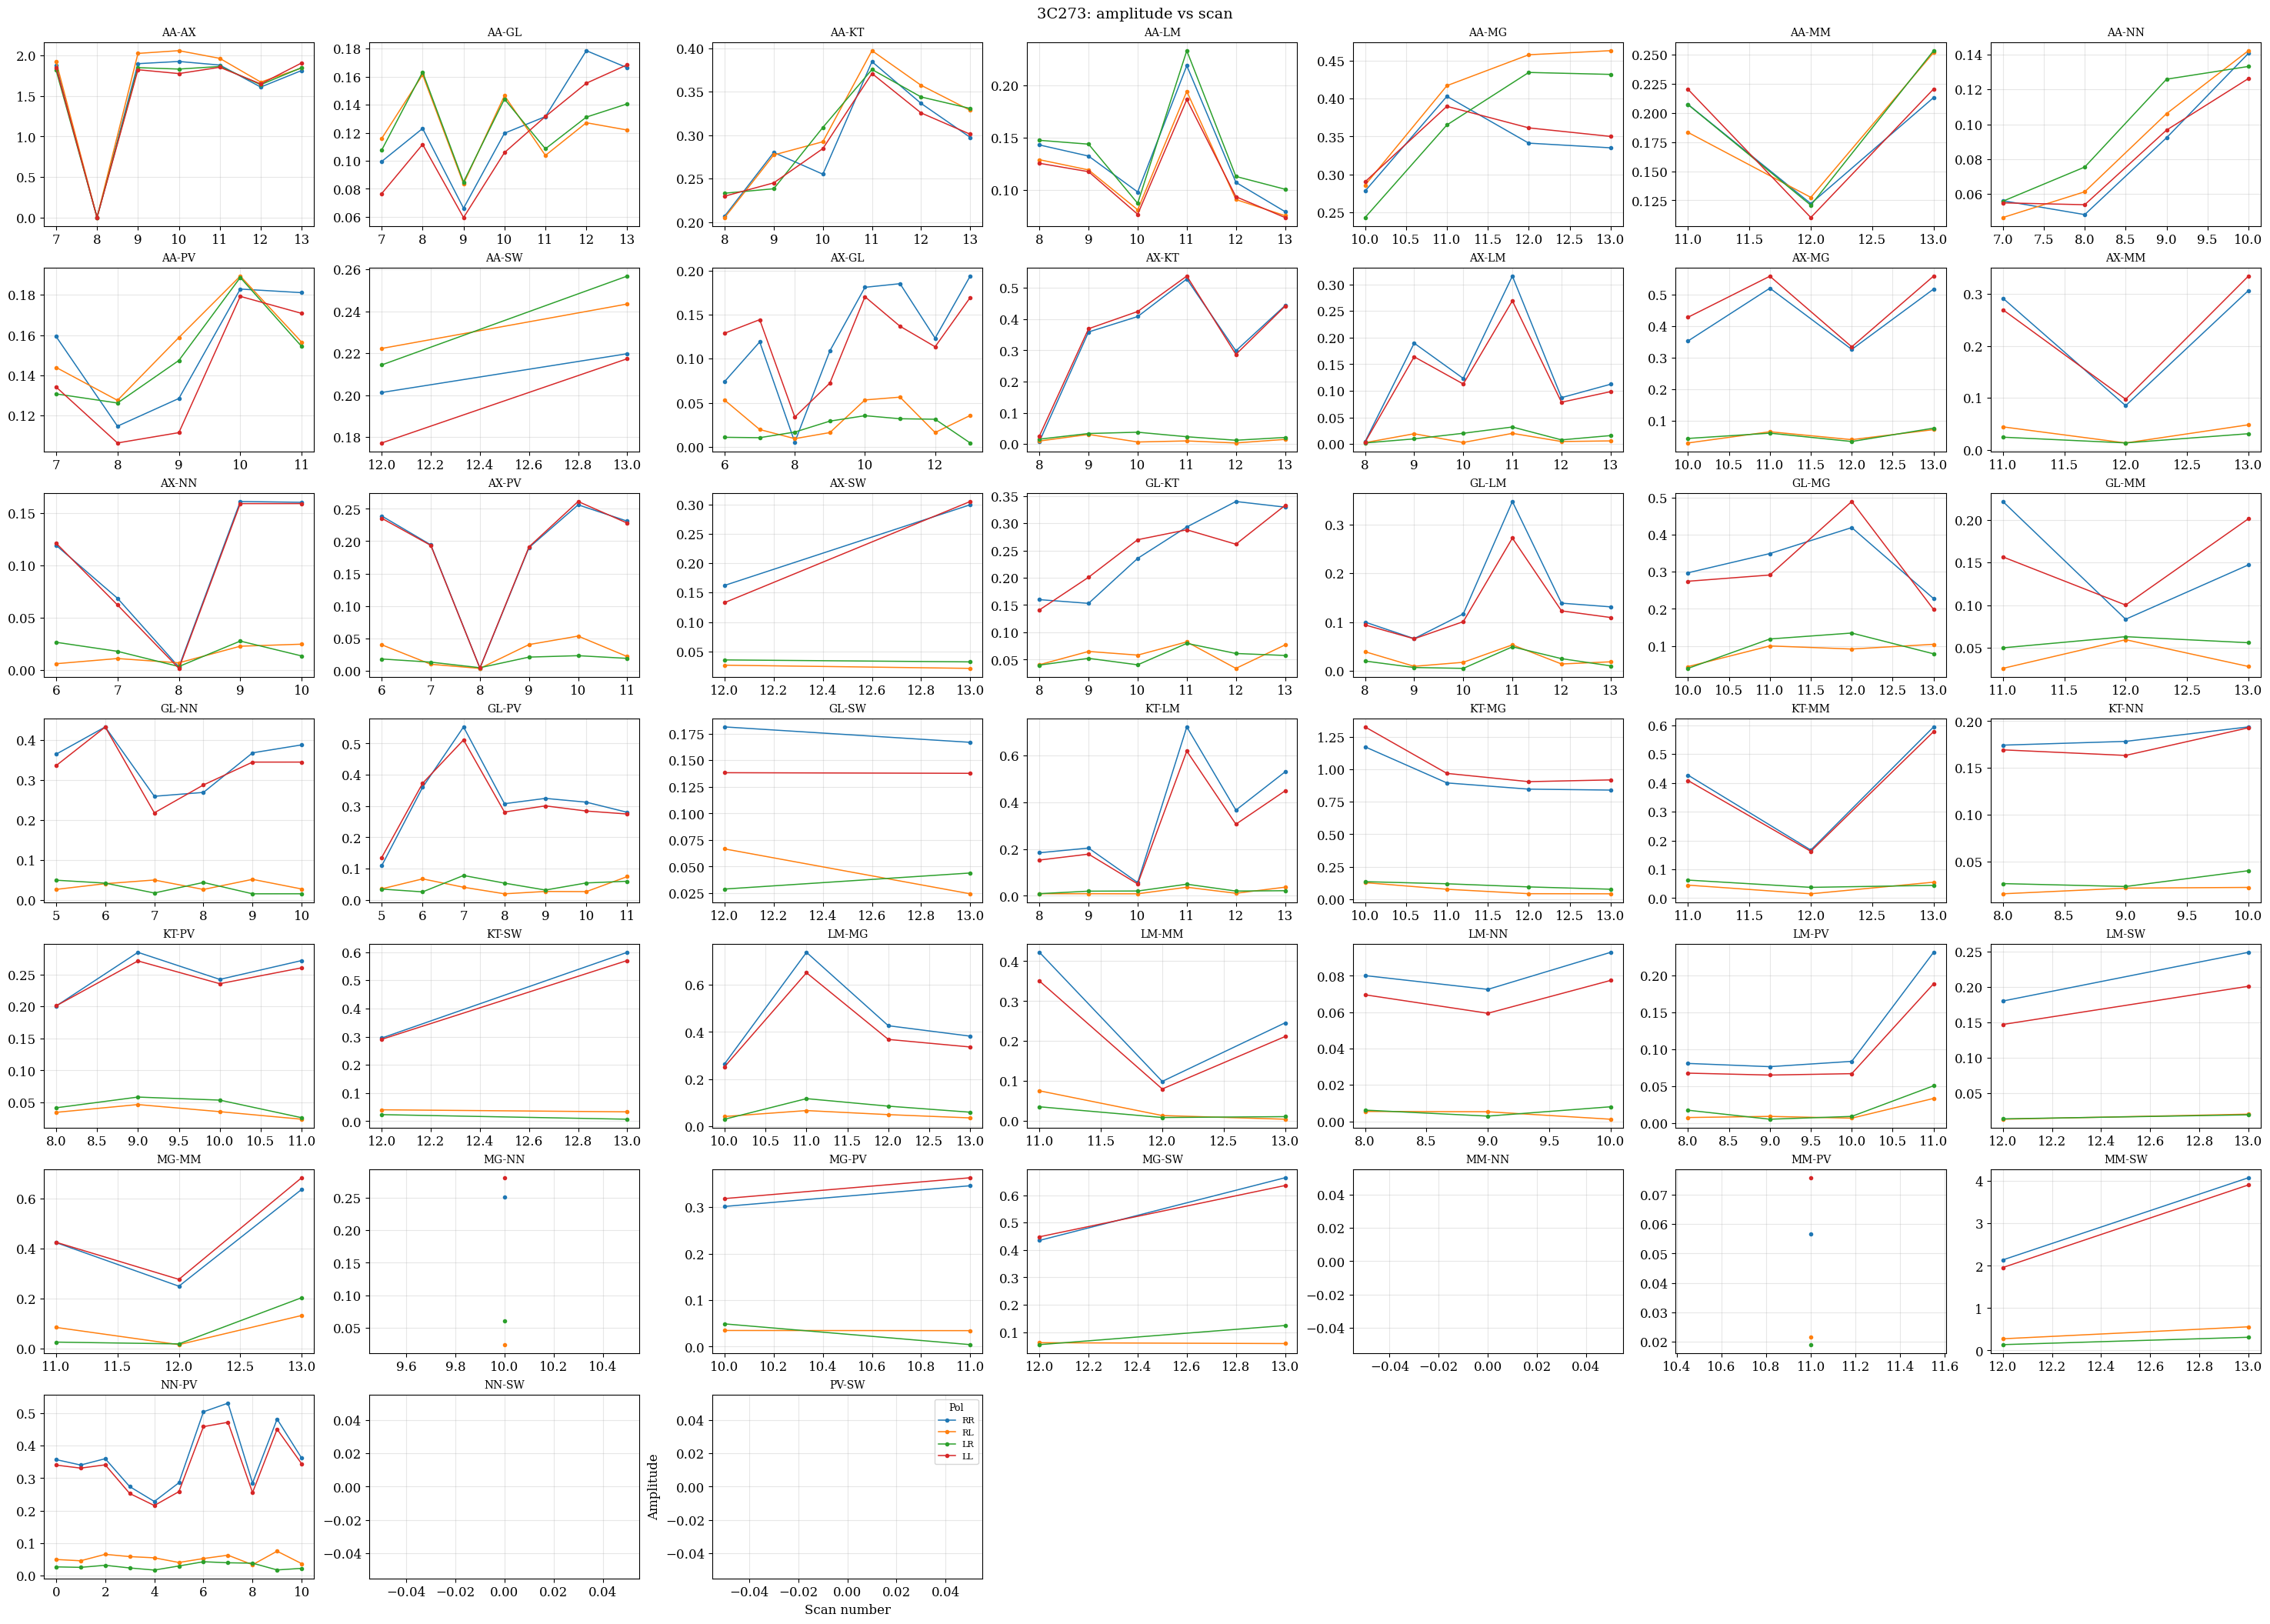

In [9]:
fig, axs, out = plot_results_amp_vs_scan_all_baselines(results, source="3C273")

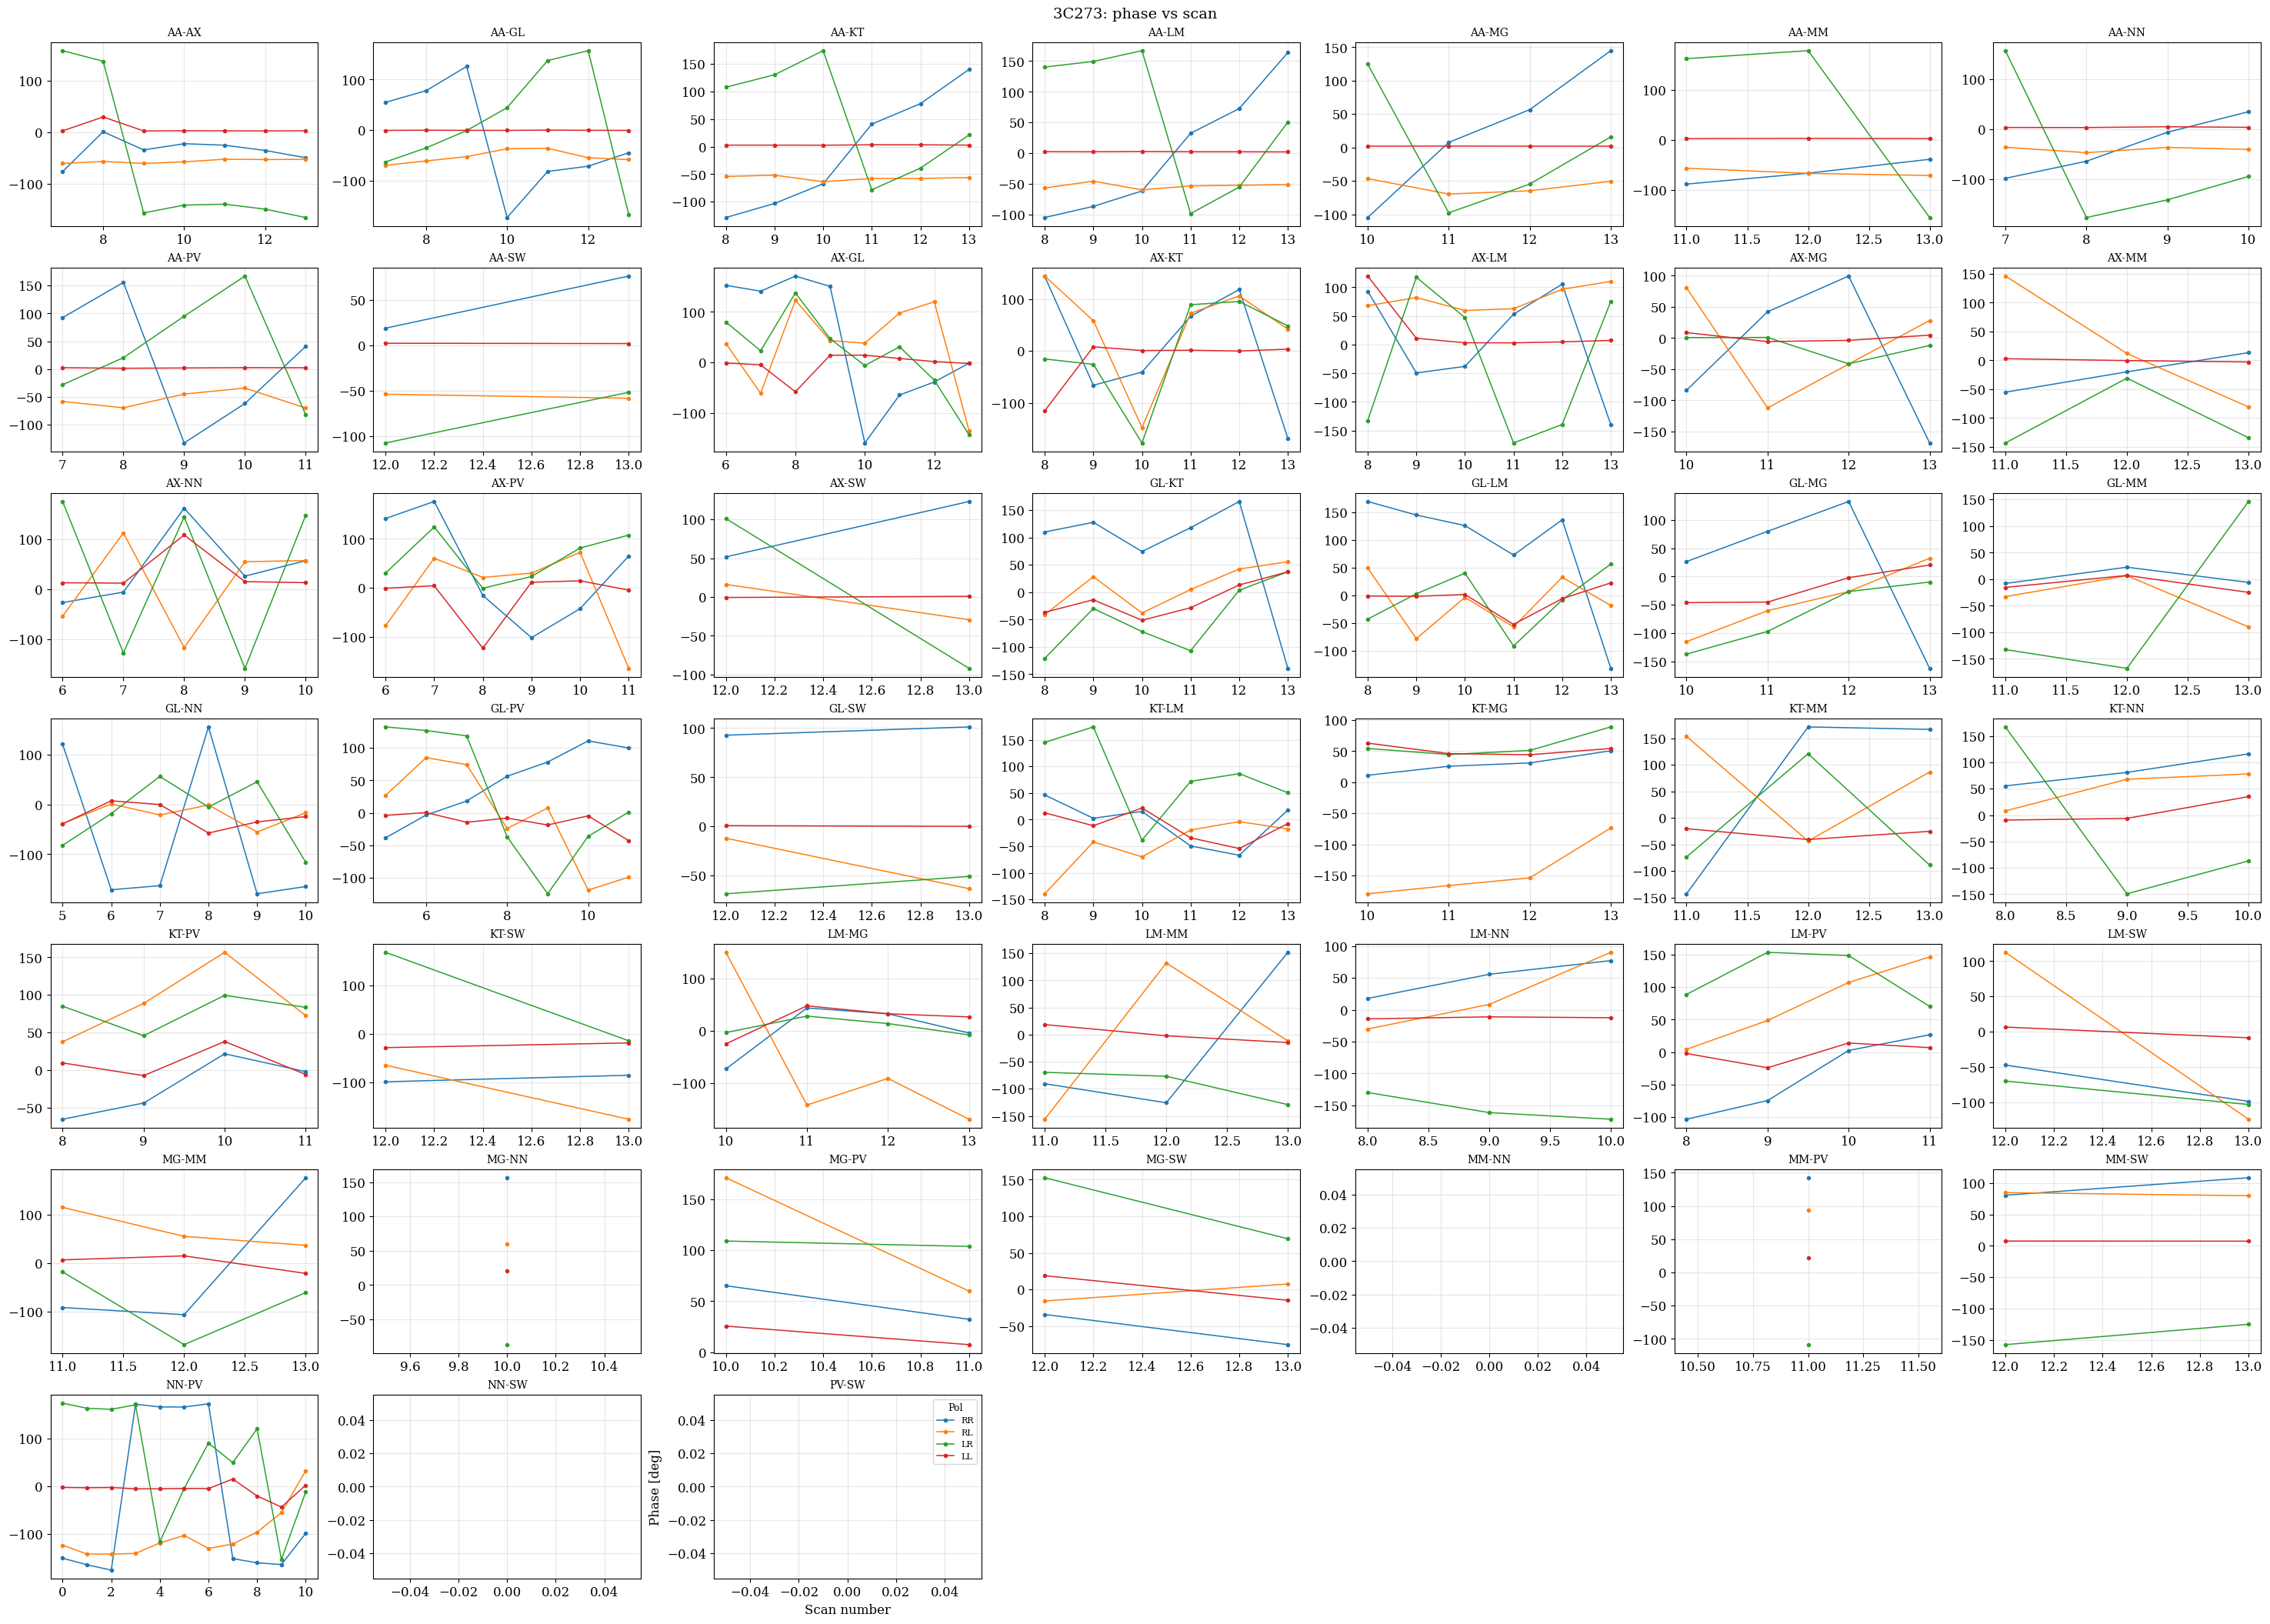

In [10]:
fig, axs, out = plot_results_phase_vs_scan_all_baselines(results, source="3C273")

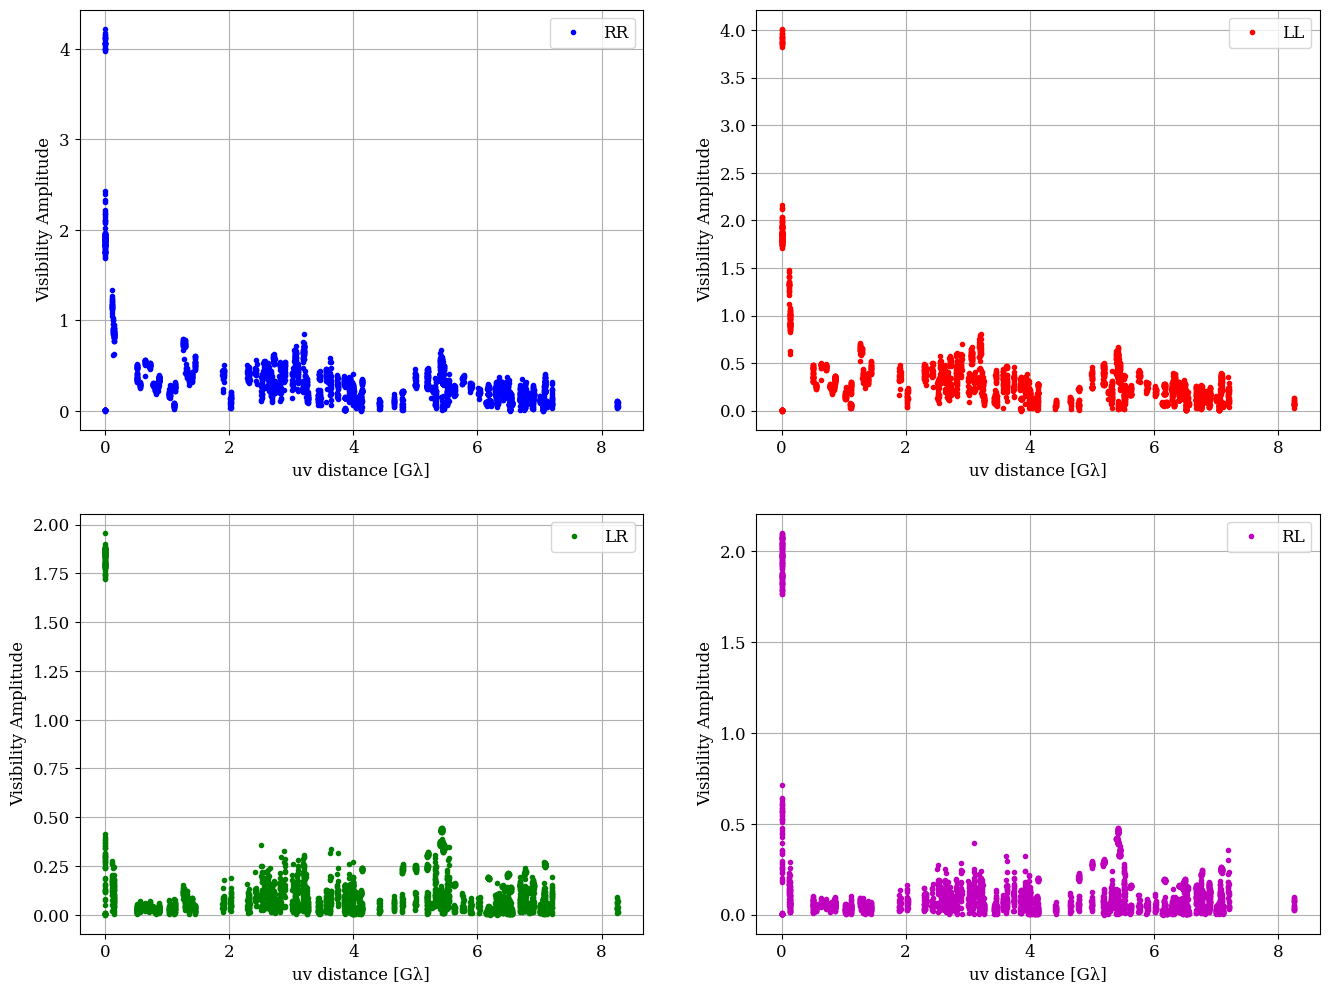

In [11]:
plot_amp_uvdist_whole_dataset(u, v, rr, rl, lr, ll, source="3C273")

In [14]:
for tmp_res in results:
    fig, ax = plot_result_phase_vs_time_all_baselines(tmp_res)
    plt.close()
    del fig, ax

    fig, ax = plot_result_amp_vs_time_all_baselines(tmp_res)
    plt.close()
    del fig, ax

### Inspect Closure Quantities 

In [12]:
result = build_scan_coherency_matrix(7, scan_ids, times, t1, t2, u, v, rr, rl, lr, ll)

In [13]:
closure = build_closure_products_from_coherency(
    result,
    exclude_stations=("AA", "ALMA"),
)

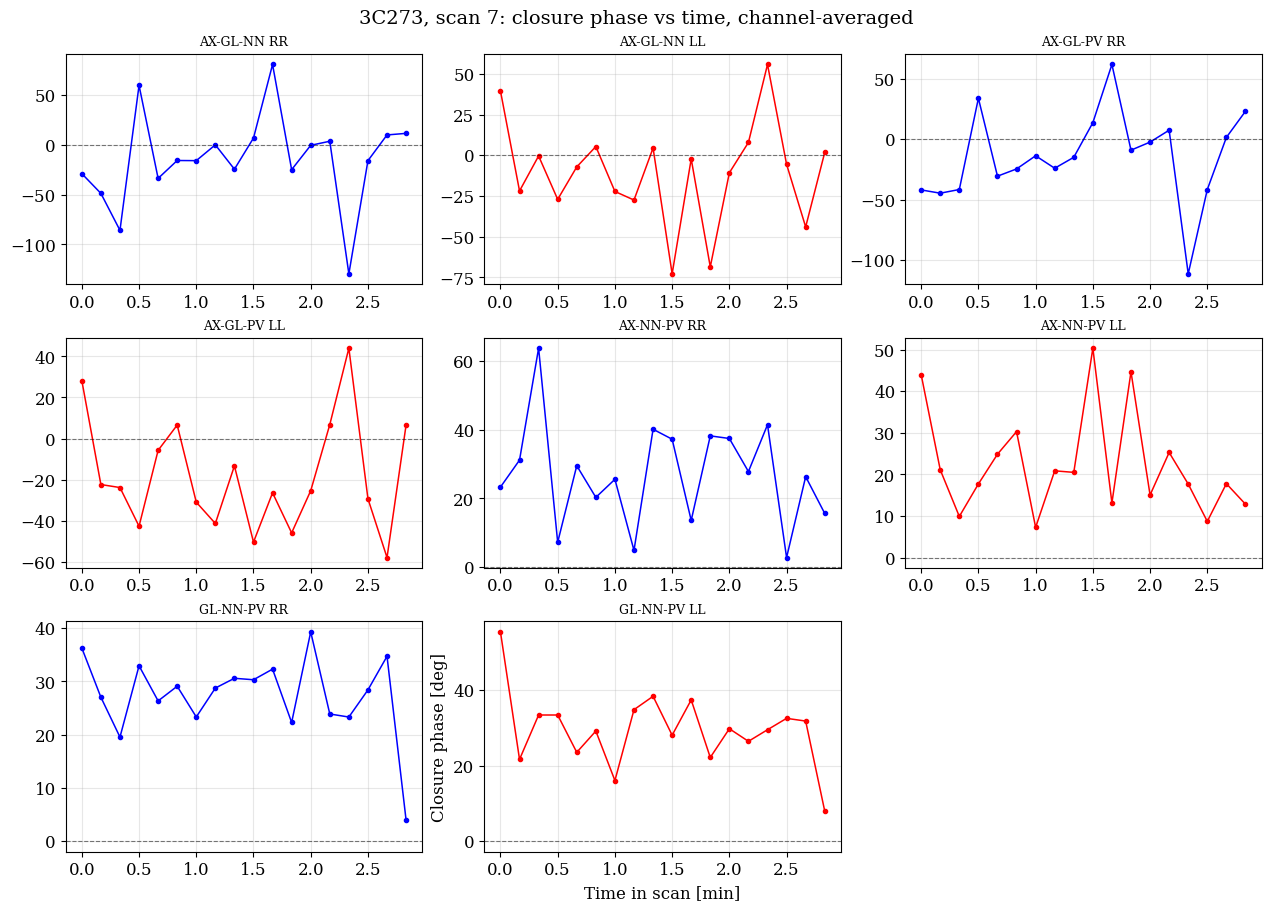

In [14]:
fig, ax = plot_closure_phase_vs_time_all_triangles(closure, source="3C273")

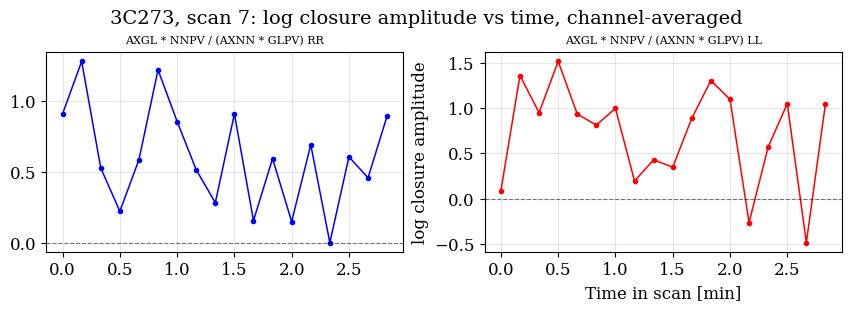

In [15]:
fig, ax = plot_closure_amp_vs_time_all_quadrangles(closure, source="3C273")